In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
#to load dataset
from datasets import load_dataset



# LOAD DATASET

In [2]:
emotion_dataset=load_dataset('dair-ai/emotion')
train_text=emotion_dataset['train']['text']
train_label=emotion_dataset['train']['label']

test_text=emotion_dataset['test']['text']
test_label=emotion_dataset['test']['label']

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  129kB            

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [3]:
label_names=emotion_dataset['train'].features['label'].names

In [4]:
label_names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [ ]:
train_label

Column([0, 0, 3, 2, 3, ...])

In [5]:
for i in train_label:
  print(label_names[i])

Streaming output truncated to the last 5000 lines.
sadness
sadness
anger
fear
love
joy
anger
sadness
sadness
joy
fear
joy
fear
love
love
anger
anger
sadness
fear
sadness
sadness
surprise
love
joy
joy
love
sadness
joy
joy
fear
sadness
anger
anger
sadness
love
fear
fear
anger
anger
joy
sadness
sadness
joy
joy
fear
sadness
joy
love
fear
anger
sadness
joy
anger
surprise
fear
joy
joy
love
fear
sadness
joy
anger
fear
anger
sadness
sadness
sadness
anger
sadness
fear
joy
anger
anger
sadness
fear
joy
anger
fear
sadness
joy
fear
joy
love
anger
fear
fear
fear
fear
joy
anger
anger
sadness
joy
sadness
joy
sadness
sadness
joy
sadness
fear
fear
joy
sadness
joy
sadness
joy
fear
anger
sadness
joy
anger
joy
joy
sadness
joy
joy
anger
anger
joy
joy
joy
sadness
joy
joy
joy
anger
anger
joy
love
joy
love
joy
joy
joy
sadness
joy
sadness
surprise
sadness
anger
anger
anger
fear
fear
joy
fear
fear
joy
anger
joy
joy
joy
love
joy
fear
sadness
sadness
surprise
sadness
sadness
anger
joy
love
fear
joy
anger
joy
surpr

In [6]:
df_train=pd.DataFrame({
    'text':train_text,
    'label':[label_names[i] for i in train_label]
})

df_test=pd.DataFrame({
    'text':test_text,
    'label':[label_names[i] for i in test_label]
})

# Exploratory Data Analysis


<Axes: xlabel='label', ylabel='count'>

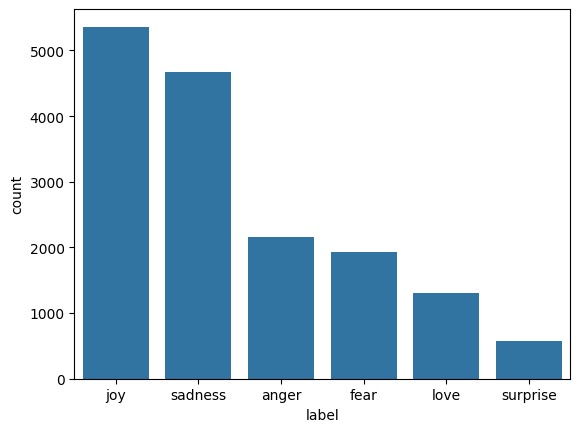

In [7]:
sns.countplot(x='label',data=df_train,order=df_train['label'].value_counts().index)

In [8]:
df_train['label'].value_counts()

,count
label,
joy,5362
sadness,4666
anger,2159
fear,1937
love,1304
surprise,572


# Data preprocessing - NLP


In [9]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_words = 10000

tokenizer=Tokenizer(num_words=max_words,oov_token='<unk>')
tokenizer.fit_on_texts(df_train['text'])

train_sequence=tokenizer.texts_to_sequences(df_train['text'])
test_sequence=tokenizer.texts_to_sequences(df_test['text'])

padded_train_sequence=pad_sequences(train_sequence,maxlen=50,padding='post',truncating='post')
padded_test_sequence=pad_sequences(test_sequence,maxlen=50,padding='post',truncating='post')

train_labels=np.array(train_label)
test_labels=np.array(test_label)

num_classes = len(np.unique(train_labels))

print(f"Vocabulary size : {len(tokenizer.word_index)}")
print(f"Max Sentence Length : {padded_train_sequence.shape[1]}")



Vocabulary size : 15213
Max Sentence Length : 50


# Shared training utilities

Compute balanced class weights to handle dataset skew and setup early stopping


In [10]:
from sklearn.utils import class_weight

class_weights=class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y = train_labels
)

class_weight_dict = dict(enumerate(class_weights))

In [11]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping=EarlyStopping(
    monitor='val_loss',
    patience =3,
    restore_best_weights=True
)


# Phase 1 - Plain Foundational Models

Train plain(non-bidirectional) simple RNN,standard LSTM and Standard GRU model

1.Simple RNN

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,SimpleRNN,Dense,Dropout

rnn_model=Sequential([
    Embedding(input_dim= max_words,output_dim=128,input_length=50),
    SimpleRNN(units=128,return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5),
    Dense(num_classes,activation='softmax')

])
rnn_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
rnn_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence,test_labels),
    epochs=20,
    batch_size=32,

    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 49ms/step - accuracy: 0.1623 - loss: 2.0577 - val_accuracy: 0.1050 - val_loss: 1.8151
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 24s 49ms/step - accuracy: 0.1431 - loss: 1.8853 - val_accuracy: 0.0355 - val_loss: 1.8458
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 24s 49ms/step - accuracy: 0.1344 - loss: 1.8196 - val_accuracy: 0.1295 - val_loss: 1.7727
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 50ms/step - accuracy: 0.1406 - loss: 1.8064 - val_accuracy: 0.0385 - val_loss: 1.8254
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step - accuracy: 0.1582 - loss: 1.8013 - val_accuracy: 0.2695 - val_loss: 1.7624
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 25s 49ms/step - accuracy: 0.1468 - loss: 1.8027 - val_accuracy: 0.0445 - val_loss: 1.8169
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step - accuracy: 0.1370 - loss: 1.7999 - val_accuracy: 0.0405 - val_loss: 1.8037
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 25s 49ms/step - accuracy: 0.1474 - loss: 1.8021 - 

In [14]:
rnn_loss,rnn_accuracy=rnn_model.evaluate(padded_test_sequence,test_labels)
print(f"rnn loss: {rnn_loss}")
print(f"rnn accuracy: {rnn_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.1405 - loss: 1.8555
rnn loss: 1.8555353879928589
rnn accuracy: 0.1404999941587448


Model 2 -> LSTM

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,SimpleRNN,Dense,Dropout,LSTM

lstm_model=Sequential([
    Embedding(input_dim= max_words,output_dim=128,input_length=50),
    LSTM(units=128,return_sequences=True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(num_classes,activation='softmax')

])
lstm_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [19]:
lstm_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence,test_labels),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)
lstm_loss,lstm_accuracy=lstm_model.evaluate(padded_test_sequence,test_labels)
print(f"lstm loss: {lstm_loss}")
print(f"lstm accuracy: {lstm_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 70s 132ms/step - accuracy: 0.1412 - loss: 1.7959 - val_accuracy: 0.1375 - val_loss: 1.7969
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 97s 194ms/step - accuracy: 0.1464 - loss: 1.7942 - val_accuracy: 0.1380 - val_loss: 1.8005
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 112s 224ms/step - accuracy: 0.1798 - loss: 1.7923 - val_accuracy: 0.0490 - val_loss: 1.7922
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 80s 159ms/step - accuracy: 0.1698 - loss: 1.7789 - val_accuracy: 0.2305 - val_loss: 1.7644
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 80s 160ms/step - accuracy: 0.2823 - loss: 1.6613 - val_accuracy: 0.2350 - val_loss: 1.7758
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 67s 134ms/step - accuracy: 0.4044 - loss: 1.3887 - val_accuracy: 0.4940 - val_loss: 1.3773
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 66s 131ms/step - accuracy: 0.6034 - loss: 0.9701 - val_accuracy: 0.6860 - val_loss: 0.9712
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 86s 139ms/step - accuracy: 0.7986 - loss: 

Model 3 -> GRU

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,SimpleRNN,Dense,Dropout,LSTM,GRU

gru_model=Sequential([
    Embedding(input_dim= max_words,output_dim=128,input_length=50),
    GRU(units=128,return_sequences=True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(num_classes,activation='softmax')

])
gru_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [18]:
gru_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence,test_labels),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping])

gru_loss,gru_accuracy=gru_model.evaluate(padded_test_sequence,test_labels)

print(f"gru loss: {gru_loss}")
print(f"gru accuracy: {gru_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 72s 136ms/step - accuracy: 0.1465 - loss: 1.7977 - val_accuracy: 0.2895 - val_loss: 1.7952
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 73s 117ms/step - accuracy: 0.1597 - loss: 1.7946 - val_accuracy: 0.0805 - val_loss: 1.8263
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 81s 116ms/step - accuracy: 0.1577 - loss: 1.7947 - val_accuracy: 0.0330 - val_loss: 1.8535
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 80s 113ms/step - accuracy: 0.1526 - loss: 1.7932 - val_accuracy: 0.1365 - val_loss: 1.8091
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.2895 - loss: 1.7952
gru loss: 1.7951505184173584
gru accuracy: 0.28949999809265137


Result of Phase 1

In [20]:
result_df=pd.DataFrame({
    'model':['rnn','lstm','gru'],
    'loss':[rnn_loss,lstm_loss,gru_loss],
    'accuracy':[rnn_accuracy,lstm_accuracy,gru_accuracy]
}).sort_values(by='accuracy',ascending=False)
result_df

,model,loss,accuracy
1,lstm,0.444970,0.8645
2,gru,1.795151,0.2895
0,rnn,1.855535,0.1405


# Phase 2 -> Advanced Bidirectional GRU

Model 4 - Advanced Stacked Bidirectional GRU

In [21]:
from tensorflow.keras.layers import Bidirectional

BiGRU = Sequential([
    Embedding(input_dim = max_words,output_dim=300,input_length=50),
    Bidirectional(GRU(units=128,return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(64)),
    Dropout(0.5),
    Dense(num_classes,activation='softmax')
])

BiGRU.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

BiGRU.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Train and Evaluate Advanced Bidirectiona GRU

In [23]:
BiGRU.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence,test_labels),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 172s 330ms/step - accuracy: 0.5496 - loss: 1.0507 - val_accuracy: 0.8790 - val_loss: 0.4529
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 203s 332ms/step - accuracy: 0.9126 - loss: 0.2535 - val_accuracy: 0.9090 - val_loss: 0.2717
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 169s 339ms/step - accuracy: 0.9436 - loss: 0.1508 - val_accuracy: 0.9170 - val_loss: 0.2783
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 167s 334ms/step - accuracy: 0.9589 - loss: 0.1137 - val_accuracy: 0.9175 - val_loss: 0.2280
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 253s 435ms/step - accuracy: 0.9665 - loss: 0.0895 - val_accuracy: 0.9195 - val_loss: 0.2533
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 215s 341ms/step - accuracy: 0.9744 - loss: 0.0745 - val_accuracy: 0.9150 - val_loss: 0.3172
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 197s 331ms/step - accuracy: 0.9784 - loss: 0.0611 - val_accuracy: 0.9170 - val_loss: 0.2907


In [25]:
BiGRU_loss,BiGRU_accuracy=BiGRU.evaluate(padded_test_sequence,test_labels)
print(f"BiGRU loss: {BiGRU_loss}")
print(f"BiGRU accuracy: {BiGRU_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.9175 - loss: 0.2280
BiGRU loss: 0.22801612317562103
BiGRU accuracy: 0.9175000190734863


# Overall Evaluation and Bias Analysis

63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step


<Axes: >

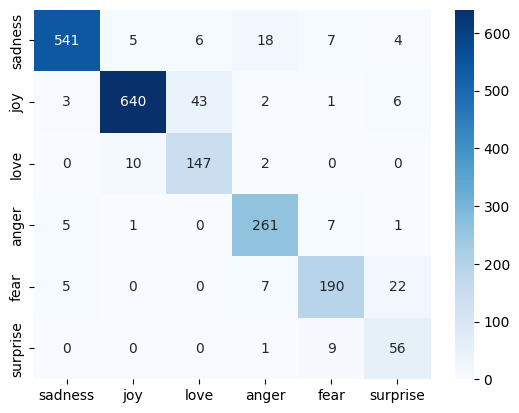

In [24]:
from sklearn.metrics import confusion_matrix

BiGRU_predictions= np.argmax(BiGRU.predict(padded_test_sequence),axis=1)

sns.heatmap(confusion_matrix(test_labels,BiGRU_predictions),annot = True,fmt='d',cmap='Blues',xticklabels=label_names,yticklabels=label_names)

In [26]:
sample_texts =[
    "I can't believe how happy I am right now , this is amazing",
    "I feel so alone and hopeless today",
    "I am furious that they cancelled the trip",
    "Arijit is my favorite singer"
]

In [27]:
sample_sequences=tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences=pad_sequences(sample_sequences,maxlen=50,padding='post',truncating='post')

sample_predictions=np.argmax(BiGRU.predict(sample_padded_sequences),axis=1)

for i in range(len(sample_texts)):
  print(f"TEXT : {sample_texts[i]}")
  print(f"PREDICTED LABEL : {label_names[sample_predictions[i]]}\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
TEXT : I can't believe how happy I am right now , this is amazing
PREDICTED LABEL : joy

TEXT : I feel so alone and hopeless today
PREDICTED LABEL : sadness

TEXT : I am furious that they cancelled the trip
PREDICTED LABEL : anger

TEXT : Arijit is my favorite singer
PREDICTED LABEL : sadness



# Save Model


Export trained model and tokenizer artifacts for API deployment


In [29]:
import os
import pickle

model_dir='Artifacts'
os.makedirs(model_dir,exist_ok=True)


BiGRU.save(os.path.join(model_dir,'BiGRU_model.keras'))

with open(os.path.join(model_dir,'tokenizer.pkl'),'wb') as file:
  pickle.dump(tokenizer,file)